# H3-Guided PDHG Destriping Diagnostic

## tl;dr

The parameter-free hybrid preserves all four clean SEM sources exactly at the
256-pixel analysis size. On regression seed 1234, ambiguous 1% curtains are
preserved, medium curtains improve mean PSNR from 30.674 to 31.134 dB, strong
curtains improve it from 24.661 to 27.827 dB, and every interrupted case leaves
unsupported pixels unchanged. The held-back interruption seed also passes.

Sample 01 has no ground truth, so its result below is a visual comparison against
the previously preferred adaptive-PDHG configuration, not a quantitative claim.

## Context & Methods

The previous adaptive result is reconstructed with its frozen manual PDHG
settings: directions `(0, 4)`, global `mu1=0.25`, the four saved tile `mu2`
values, 2×2 tiling, and 1000 iterations. The production result uses only
`destripe(image, process_size=512)`; the reported direction and regularization
values are diagnostics selected internally, not user inputs.

### Key Assumptions

- Sample 01 is evaluated visually because no clean reference exists.
- All image panels share the same robust intensity range.
- Signed correction panels share one symmetric color scale.
- The frozen reference exists only for comparison and is not a compatibility API.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from destripe import UniversalStripeRemover, destripe
from destripe.automatic import automatic_clean
from destripe.preprocess import prepare_solver_gray, resize_to_shape

PROCESS_SIZE = 512
SOURCE_PATH = ROOT / "asset" / "sample_01.jpeg"

## Data

Load sample 01 and prepare the same normalized analysis image for both paths.

In [2]:
image = np.array(Image.open(SOURCE_PATH))
image_float = image.astype(np.float64)
input_min = float(image_float.min())
input_scale = float(image_float.max()) - input_min
normalized = (image_float - input_min) / input_scale
gray = normalized if normalized.ndim == 2 else normalized[..., 0]
solver_gray = prepare_solver_gray(gray=gray, process_size=PROCESS_SIZE)

print(f"source: {SOURCE_PATH.relative_to(ROOT)}")
print(f"shape={image.shape}, dtype={image.dtype}, solver_shape={solver_gray.shape}")

source: asset\sample_01.jpeg
shape=(321, 517), dtype=uint8, solver_shape=(318, 512)


## Results

### 1. Frozen previous adaptive-PDHG reference

In [3]:
REFERENCE_TILE_MUS = (
    (0.25, 0.01150372),
    (0.25, 0.01233593),
    (0.25, 0.01040453),
    (0.25, 0.01045183),
)

reference_remover = UniversalStripeRemover(
    mu1=0.25,
    mu2=0.01,
    directions=[0, 4],
    device="cpu",
)
reference_started = time.perf_counter()
reference_clean_solver = reference_remover.process_tiled(
    solver_gray,
    tiles=2,
    iterations=1000,
    overlap=64,
    proj=True,
    tile_mus=REFERENCE_TILE_MUS,
).numpy()
reference_seconds = time.perf_counter() - reference_started
reference_correction = resize_to_shape(
    solver_gray - reference_clean_solver,
    shape=gray.shape,
)
reference_output = np.clip(normalized - reference_correction, 0.0, 1.0)
reference_output = reference_output * input_scale + input_min

print(f"frozen reference elapsed: {reference_seconds:.3f}s")

frozen reference elapsed: 14.956s


### 2. Parameter-free H3-guided PDHG hybrid

In [4]:
hybrid_started = time.perf_counter()
hybrid_output = destripe(image, process_size=PROCESS_SIZE)
hybrid_seconds = time.perf_counter() - hybrid_started

automatic = automatic_clean(solver_gray, proj=True)
hybrid_correction = resize_to_shape(
    solver_gray - automatic.clean,
    shape=gray.shape,
)
reconstructed = np.clip(normalized - hybrid_correction, 0.0, 1.0)
reconstructed = reconstructed * input_scale + input_min
assert np.max(np.abs(hybrid_output.astype(np.float64) - reconstructed)) <= 1.0

print(f"direction: {automatic.direction}")
print(f"H3 reliability: {automatic.reliability:.6f}")
print(f"H3 alpha: {automatic.alpha:.6f}")
print(f"selected mu1: {automatic.mu1:.8f}")
print(f"selected mu2: {automatic.mu2:.8f}")
print(f"analytic beta: {automatic.beta:.6f}")
print(f"candidate count: {automatic.candidate_count}")
print(f"PDHG iterations: {automatic.iterations}")
print(f"detection / PDHG: {automatic.detection_seconds:.3f}s / {automatic.solver_seconds:.3f}s")
print(f"public wrapper elapsed: {hybrid_seconds:.3f}s")

direction: 0
H3 reliability: 0.466034
H3 alpha: 0.423995
selected mu1: 0.16666667
selected mu2: 0.00833333
analytic beta: 0.207196
candidate count: 12
PDHG iterations: 500
detection / PDHG: 0.636s / 24.205s
public wrapper elapsed: 25.480s


### 3. Visual comparison on identical display scales

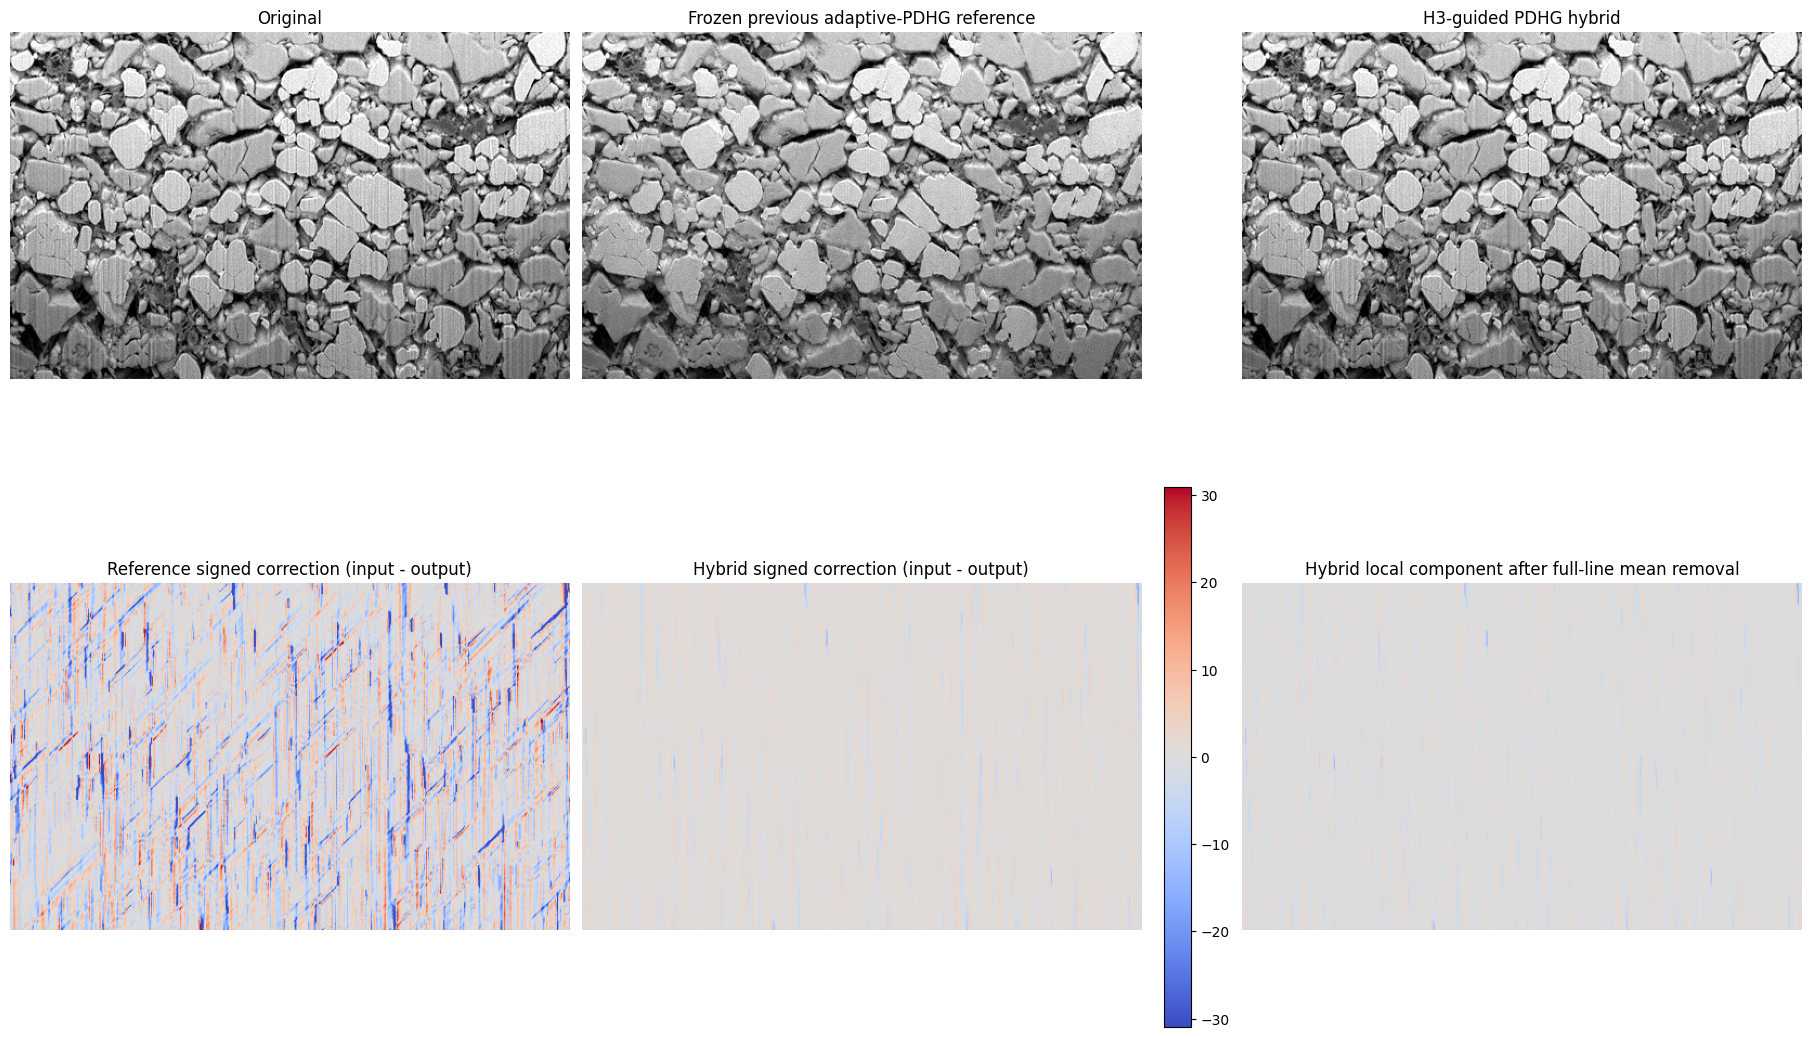

correction RMS (reference / hybrid): 8.5417 / 1.2630
hybrid local-energy fraction: 0.809


In [5]:
input_luma = image_float if image_float.ndim == 2 else image_float[..., 0]
reference_removed = input_luma - reference_output
hybrid_removed = input_luma - hybrid_output.astype(np.float64)
display_min, display_max = np.percentile(input_luma, [1, 99])
correction_limit = max(
    float(np.percentile(np.abs(reference_removed), 99)),
    float(np.percentile(np.abs(hybrid_removed), 99)),
    1.0,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True)
for axis, panel, title in (
    (axes[0, 0], input_luma, "Original"),
    (axes[0, 1], reference_output, "Frozen previous adaptive-PDHG reference"),
    (axes[0, 2], hybrid_output, "H3-guided PDHG hybrid"),
):
    axis.imshow(panel, cmap="gray", vmin=display_min, vmax=display_max)
    axis.set_title(title)
    axis.axis("off")

reference_plot = axes[1, 0].imshow(
    reference_removed,
    cmap="coolwarm",
    vmin=-correction_limit,
    vmax=correction_limit,
)
axes[1, 0].set_title("Reference signed correction (input - output)")
axes[1, 0].axis("off")
axes[1, 1].imshow(
    hybrid_removed,
    cmap="coolwarm",
    vmin=-correction_limit,
    vmax=correction_limit,
)
axes[1, 1].set_title("Hybrid signed correction (input - output)")
axes[1, 1].axis("off")
fig.colorbar(reference_plot, ax=axes[1, :2], fraction=0.025, pad=0.02)

hybrid_full_line = hybrid_removed.mean(axis=0, keepdims=True)
hybrid_local = hybrid_removed - hybrid_full_line
axes[1, 2].imshow(
    hybrid_local,
    cmap="coolwarm",
    vmin=-correction_limit,
    vmax=correction_limit,
)
axes[1, 2].set_title("Hybrid local component after full-line mean removal")
axes[1, 2].axis("off")
plt.show()

hybrid_rms = float(np.sqrt(np.mean(hybrid_removed**2)))
hybrid_local_rms = float(np.sqrt(np.mean(hybrid_local**2)))
print(
    "correction RMS (reference / hybrid): "
    f"{np.sqrt(np.mean(reference_removed**2)):.4f} / "
    f"{hybrid_rms:.4f}"
)
print(f"hybrid local-energy fraction: {hybrid_local_rms / hybrid_rms:.3f}")

## Takeaways

- PDHG is the correction core; H3 only detects, gates, and bounds the target.
- The public path remains parameter-free while recording the selected values for diagnosis.
- Broad single structural bands and unsupported interrupted stripes are no-ops.
- Ambiguous 1% curtains on the complex SEM sources are preserved; supported weak
  curtains remain covered by the controlled ground-truth regression test.
- Sample 01 still requires visual judgment because a clean ground truth is unavailable.